# Experimentos do Trabalho 3 - Reconhecimento de Padrões
- Aluno: Lucas José Lemos Braz

### 1. Imports e Configurações

In [17]:
import time
import warnings
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Adicionando o diretório raiz ao path para importar os modelos
sys.path.append(os.path.abspath("../../.."))
from classificao_padroes.models_trabalho3 import analyze_invertibility

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### 2. Carregamento dos Dados
Nesta seção, carregamos os datasets do robô Wall-Following.
- `sensor_readings_24.data`: 24 sensores de ultrassom.
- `sensor_readings_4.data`: 4 sensores de ultrassom simplificados.

In [18]:
# Caminhos relativos para os arquivos de dados
data_path_24 = "../../data/interin/wall+following+robot+navigation+data/sensor_readings_24.data"
# Nomes das colunas
col_names_24 = [f"US{i+1}" for i in range(24)] + ["Class"]

# Carregando os datasets
data_24_df = pd.read_csv(data_path_24, names=col_names_24)

# Separando features (X)
X_24 = data_24_df.drop("Class", axis=1).values

print(f"Dataset 24 sensores: {data_24_df.shape}")

Dataset 24 sensores: (5456, 25)


,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US15,US16,US17,US18,US19,US20,US21,US22,US23,US24
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,2.205772,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.715435,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.495000,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.860000,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,1.328500,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,4.436250,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250
max,5.000000,5.025000,5.029000,5.017000,5.000000,5.005000,5.008000,5.087000,5.000000,5.022000,...,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000


<Axes: xlabel='Class'>

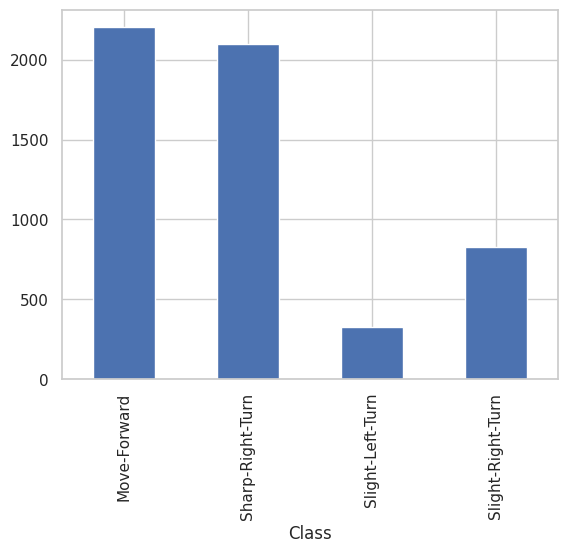

In [24]:
display(data_24_df.describe())
data_24_df.groupby("Class").size().plot(kind='bar')

### 3. Funções Auxiliares
Definimos as funções para cálculo de covariância, norma e utilitários para plotagem e benchmarking.
Agora incluímos também os métodos `mcovar1`, `mcovar2` e `mcovar4`.

### 4. Análise da Matriz de Covariância
Visualização da matriz de covariância para ambos os casos.

In [19]:
analyze_invertibility(data_24_df, "24 Sensores")

Análise de Invertibilidade: 24 Sensores
Global -> Posto: 24, Cond: 2.05e+01, RCond: 4.87e-02
Classe Move-Forward -> Posto: 24, Cond: 5.35e+01, RCond: 1.87e-02
Classe Sharp-Right-Turn -> Posto: 24, Cond: 3.13e+01, RCond: 3.20e-02
Classe Slight-Left-Turn -> Posto: 24, Cond: 1.73e+02, RCond: 5.77e-03
Classe Slight-Right-Turn -> Posto: 24, Cond: 1.96e+02, RCond: 5.10e-03
--------------------------------------------------


### Calculando norma das matrizes de covariância

In [5]:
# Calculando a norma entre a matriz de covariancia e a matriz de covariancia de referencia para cada metodo.
mcovars = [mcovar1, mcovar2, mcovar3, mcovar4]
C_ref_4 = np.cov(X_4.T)
C_ref_24 = np.cov(X_24.T)
normas_4 = []
normas_24 = []
print("Norma p/ 4 sensores.")
for i in range(4):
    C = mcovars[i](X_4.T)
    norma = np.linalg.norm(C - C_ref_4)
    normas_4.append(norma)
    print(f"Mcovar {i+1} | norma(C - C_ref): {norma}")

print("-" * 50)
print("Norma p/ 24 sensores.")
for i in range(4):
    C = mcovars[i](X_24.T)
    norma = np.linalg.norm(C - C_ref_24)
    normas_24.append(norma)
    print(f"Mcovar {i+1} | norma(C - C_ref): {norma}")


Norma p/ 4 sensores.
Mcovar 1 | norma(C - C_ref): 0.0001611620742082004
Mcovar 2 | norma(C - C_ref): 0.00016116207420584133
Mcovar 3 | norma(C - C_ref): 0.00016116207420160746
Mcovar 4 | norma(C - C_ref): 0.00016116207420574234
--------------------------------------------------
Norma p/ 24 sensores.
Mcovar 1 | norma(C - C_ref): 0.00212266396148315
Mcovar 2 | norma(C - C_ref): 0.002122663961456295
Mcovar 3 | norma(C - C_ref): 0.0021226639614547486
Mcovar 4 | norma(C - C_ref): 0.0021226639614562023


### 5. Comparativo de Desempenho (Lado a Lado)
Executamos o benchmark para ambos os datasets, agora incluindo os métodos externos `mcovar1`, `mcovar2`, e `mcovar4`.
Note que `mcovar1` utiliza um loop explícito e pode ser significativamente mais lento.

Executando benchmark para 24 sensores (100 rodadas)...
Executando benchmark para 4 sensores (100 rodadas)...


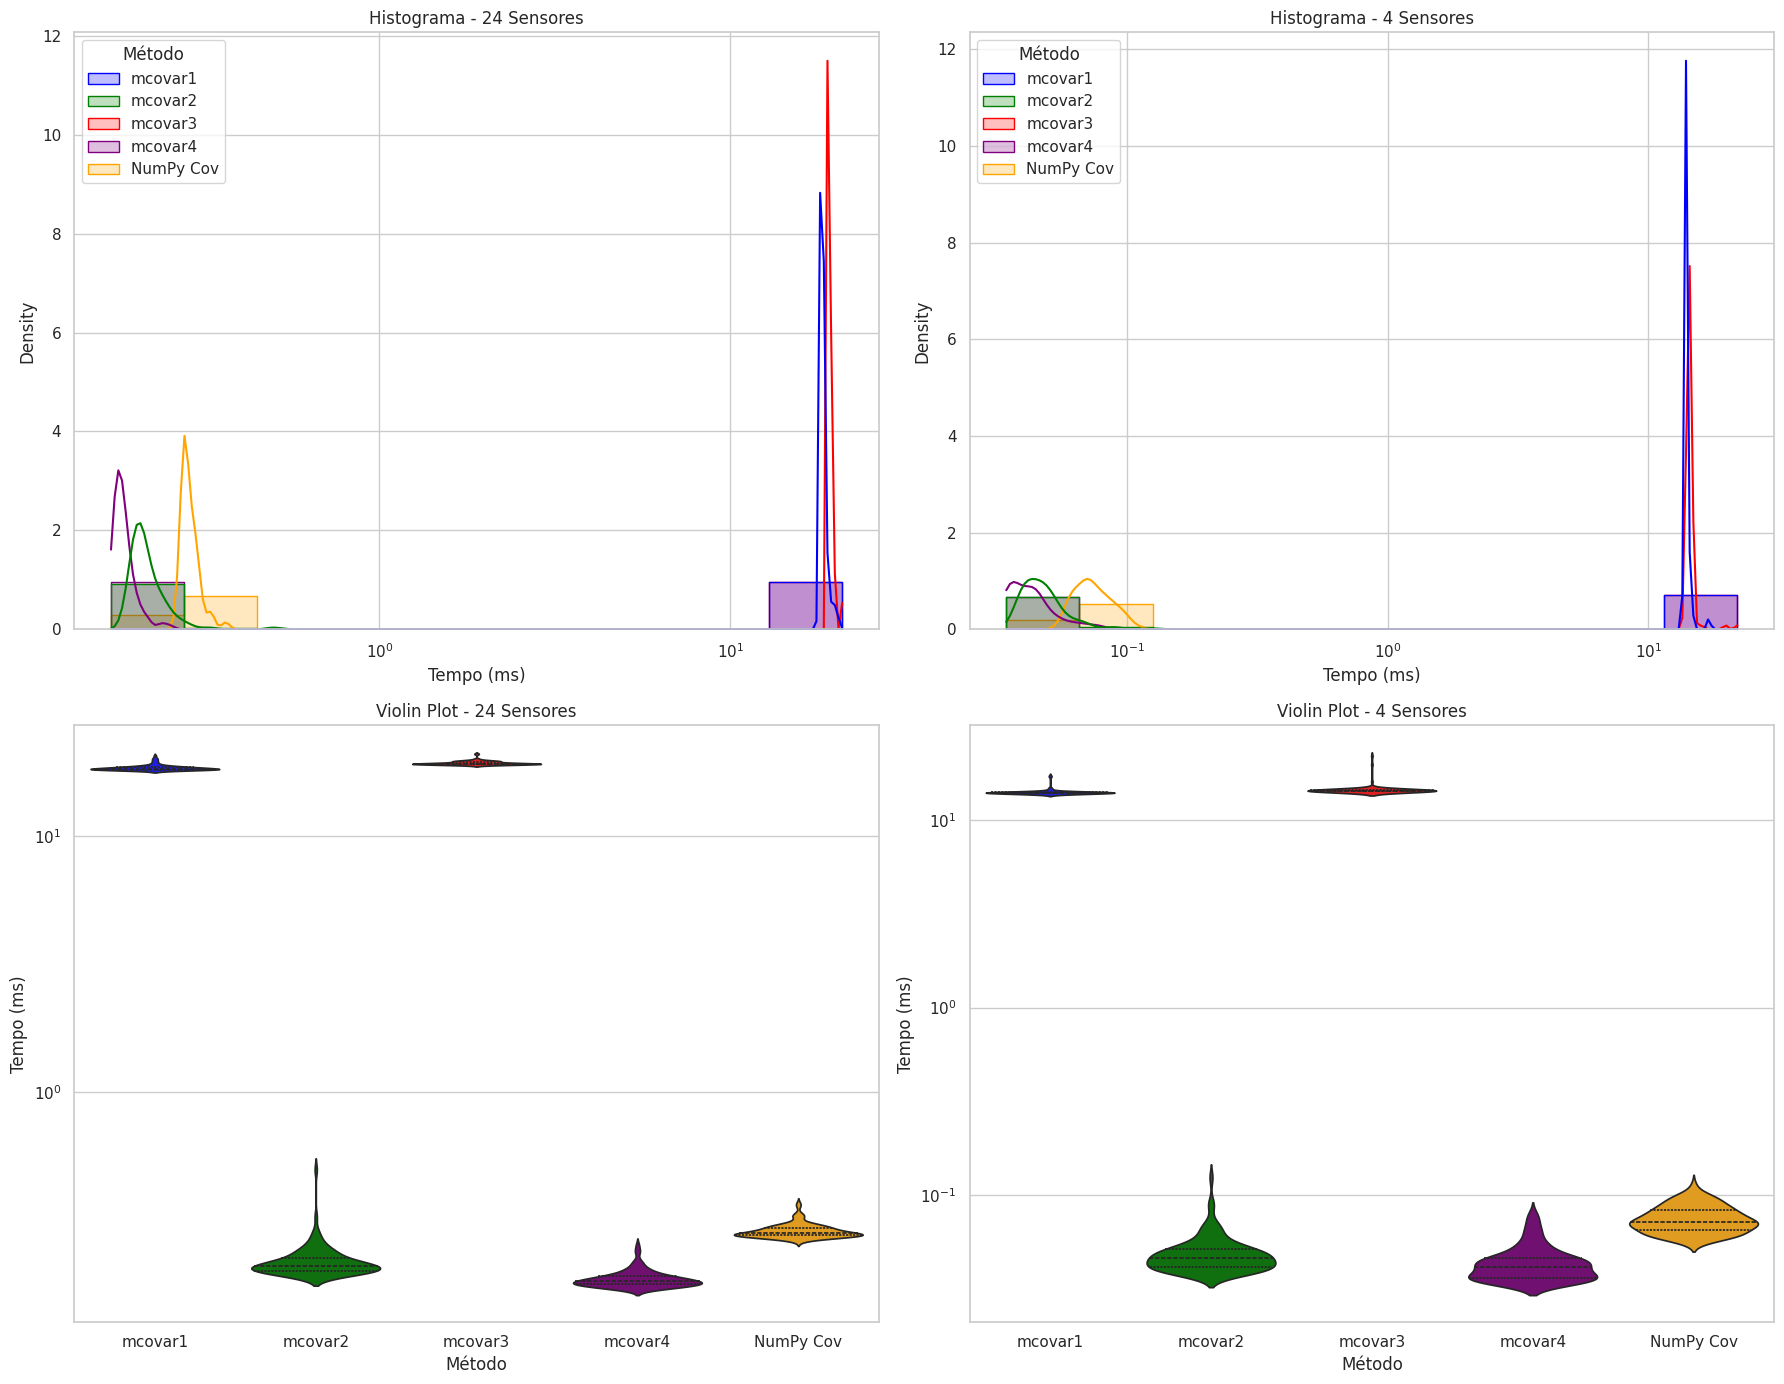

In [6]:
# 1. Executar Benchmarks
print("Executando benchmark para 24 sensores (100 rodadas)...")
results_24 = run_benchmark(X_24)

print("Executando benchmark para 4 sensores (100 rodadas)...")
results_4 = run_benchmark(X_4)

# 2. Preparar DataFrames
def prepare_df(results):
    data_list = []
    for method, times in results.items():
        for t in times:
            # Convertendo segundos para milissegundos
            data_list.append({'Tempo (ms)': t * 1000, 'Método': method})
    return pd.DataFrame(data_list)

df_24 = prepare_df(results_24)
df_4 = prepare_df(results_4)

# 3. Plotagem Lado a Lado (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Paleta de Cores
color_palette = {
    'mcovar1': 'blue',
    'mcovar2': 'green',
    'mcovar3': 'red',
    'mcovar4': 'purple',
    'NumPy Cov': 'orange'
}

# Histograma - 24 Sensores
sns.histplot(data=df_24, x='Tempo (ms)', hue='Método', kde=True, element="step", ax=axes[0, 0], palette=color_palette, log_scale=True, stat="density")
axes[0, 0].set_title('Histograma - 24 Sensores')

# Histograma - 4 Sensores
sns.histplot(data=df_4, x='Tempo (ms)', hue='Método', kde=True, element="step", ax=axes[0, 1], palette=color_palette, log_scale=True, stat="density")
axes[0, 1].set_title('Histograma - 4 Sensores')

# Violin Plot - 24 Sensores
sns.violinplot(data=df_24, x='Método', y='Tempo (ms)', inner="quartile", ax=axes[1, 0], palette=color_palette, log_scale=True)
axes[1, 0].set_title('Violin Plot - 24 Sensores')

# Violin Plot - 4 Sensores
sns.violinplot(data=df_4, x='Método', y='Tempo (ms)', inner="quartile", ax=axes[1, 1], palette=color_palette, log_scale=True)
axes[1, 1].set_title('Violin Plot - 4 Sensores')

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from IPython.display import display

def print_stats(results, title):
    df = pd.DataFrame([
        [method, np.mean(times) * 1000, np.std(times) * 1000]
        for method, times in results.items()
    ], columns=["Método", "Média (ms)", "Desvio (ms)"])
    print(f"\n{title}")
    display(df)

print_stats(results_24, "Resultados Estatísticos (24 Sensores)")
print_stats(results_4, "Resultados Estatísticos (4 Sensores)")


Resultados Estatísticos (24 Sensores)


,Método,Média (ms),Desvio (ms)
0,mcovar1,18.410398,0.448579
1,mcovar2,0.220544,0.036036
2,mcovar3,19.228462,0.336940
3,mcovar4,0.187585,0.014553
4,NumPy Cov,0.288906,0.018227



Resultados Estatísticos (4 Sensores)


,Método,Média (ms),Desvio (ms)
0,mcovar1,14.052144,0.466747
1,mcovar2,0.048954,0.012270
2,mcovar3,14.480223,0.944578
3,mcovar4,0.043712,0.009762
4,NumPy Cov,0.075049,0.012290


### Testando estatisticas sobre os resultados
- Agora testaremos se o calculo de covariancia do numpy e os metodos implementados, entre si, são estatisticamente diferentes, estamos interessados especialmente se `mcovar1` e `mcovar3` são estatisticamente diferentes. Assim como `mcovar4`e `NumPy Cov`.

In [8]:
from scipy.stats import mannwhitneyu
df_24_m1 = df_24[df_24['Método'] == 'mcovar1']
df_24_m2 = df_24[df_24['Método'] == 'mcovar2']
df_24_m3 = df_24[df_24['Método'] == 'mcovar3']
df_24_m4 = df_24[df_24['Método'] == 'mcovar4']
df_24_m5 = df_24[df_24['Método'] == 'NumPy Cov']

In [9]:
stats, p = mannwhitneyu(df_24_m5['Tempo (ms)'], df_24_m4['Tempo (ms)'])
if p < 0.05:
    print("Existem diferenças significativas entre os métodos mcovar4 e Numpy Cov")
else:
    print("Não existem diferenças significativas entre os métodos")

Existem diferenças significativas entre os métodos mcovar4 e Numpy Cov


In [10]:
stats, p = mannwhitneyu(df_24_m2['Tempo (ms)'], df_24_m4['Tempo (ms)'])
if p < 0.05:
    print("Existem diferenças significativas entre os métodos mcovar2 e mcovar4")
else:
    print("Não existem diferenças significativas entre os métodos")

Existem diferenças significativas entre os métodos mcovar2 e mcovar4


In [11]:
stats, p = mannwhitneyu(df_24_m1['Tempo (ms)'], df_24_m3['Tempo (ms)'])
if p < 0.05:
    print("Existem diferenças significativas entre os métodos mcovar1 e mcovar3")
else:
    print("Não existem diferenças significativas entre os métodos")

Existem diferenças significativas entre os métodos mcovar1 e mcovar3


## Q3 - Avaliação da invertibilidade com base no metodo mais rapido.

In [12]:
data_24_df.head()

,US1,US2,US3,US4,US5,US6,US7,US8,US9,US10,...,US16,US17,US18,US19,US20,US21,US22,US23,US24,Class
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


In [13]:
# Usando mcovar4 iremos estimar a matriz de covariancia de cada classe.
import numpy as np

def analyze_invertibility(df, label):
    print(f"Análise de Invertibilidade: {label}")
    X = df.drop(columns=['Class'])
    y = df['Class']
    
    # Matriz de Covariância Global
    cov_global = mcovar4(X)
    rank_g = np.linalg.matrix_rank(cov_global)
    cond_g = np.linalg.cond(cov_global)
    rcond_g = 1 / cond_g
    print(f"Global -> Posto: {rank_g}, Cond: {cond_g:.2e}, RCond: {rcond_g:.2e}")
    
    # Matrizes de Covariância por Classe
    for c in np.unique(y):
        X_c = X[y == c]
        cov_c = mcovar4(X_c)
        rank_c = np.linalg.matrix_rank(cov_c)
        cond_c = np.linalg.cond(cov_c)
        rcond_c = 1 / cond_c
        print(f"Classe {c} -> Posto: {rank_c}, Cond: {cond_c:.2e}, RCond: {rcond_c:.2e}")
    print("-" * 50)

analyze_invertibility(data_24_df, "data_24_df")
analyze_invertibility(data_4_df, "data_4_df")


Análise de Invertibilidade: data_24_df
Global -> Posto: 23, Cond: 4.61e+20, RCond: 2.17e-21
Classe Move-Forward -> Posto: 23, Cond: 3.39e+20, RCond: 2.95e-21
Classe Sharp-Right-Turn -> Posto: 23, Cond: 2.65e+20, RCond: 3.77e-21
Classe Slight-Left-Turn -> Posto: 23, Cond: 4.02e+19, RCond: 2.49e-20
Classe Slight-Right-Turn -> Posto: 23, Cond: 2.09e+20, RCond: 4.78e-21
--------------------------------------------------
Análise de Invertibilidade: data_4_df
Global -> Posto: 3, Cond: 5.14e+34, RCond: 1.94e-35
Classe Move-Forward -> Posto: 3, Cond: 6.19e+33, RCond: 1.62e-34
Classe Sharp-Right-Turn -> Posto: 3, Cond: 2.07e+34, RCond: 4.84e-35
Classe Slight-Left-Turn -> Posto: 3, Cond: 3.79e+18, RCond: 2.64e-19
Classe Slight-Right-Turn -> Posto: 3, Cond: 6.31e+34, RCond: 1.58e-35
--------------------------------------------------


### As matrizes acimas são singulares, não possuem posto completo. Assim, não podem ser invertidas e iremos regularizar.

In [14]:
def reg_matriz(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adiciona regularização a uma matriz de covariância.
    """
    
    lamb = 0.1
    lambI = lamb * np.eye(df.shape[1])
    return df + lambI

In [15]:
def inverter_reg(df, label):
    print(f"Análise de Invertibilidade: {label}")
    X = df.drop(columns=['Class'])
    y = df['Class']
    
    # Matriz de Covariância Global
    cov_global = mcovar4(X)

    cov_global = reg_matriz(cov_global)
    
    # Tentar inverter, se possivel, retornar mensagem de erro
    try:
        np.linalg.inv(cov_global)
        print("Global -> Invertível")
    except np.linalg.LinAlgError:
        print("Global -> Não Invertível")

    rank_g = np.linalg.matrix_rank(cov_global)
    cond_g = np.linalg.cond(cov_global)
    rcond_g = 1 / cond_g
    print(f"Global -> Posto: {rank_g}, Cond: {cond_g:.2e}, RCond: {rcond_g:.2e}")
    
    # Matrizes de Covariância por Classe
    for c in np.unique(y):
        X_c = X[y == c]
        cov_c = mcovar4(X_c)

        cov_c = reg_matriz(cov_c)

        try:
            np.linalg.inv(cov_c)
            print(f"Classe {c} -> Invertível")
        except np.linalg.LinAlgError:
            print(f"Classe {c} -> Não Invertível")
        
        rank_c = np.linalg.matrix_rank(cov_c)
        cond_c = np.linalg.cond(cov_c)
        rcond_c = 1 / cond_c
        print(f"Classe {c} -> Posto: {rank_c}, Cond: {cond_c:.2e}, RCond: {rcond_c:.2e}")
    print("-" * 50)

analyze_invertibility(data_24_df, "data_24_df")
analyze_invertibility(data_4_df, "data_4_df")

Análise de Invertibilidade: data_24_df
Global -> Posto: 23, Cond: 4.61e+20, RCond: 2.17e-21
Classe Move-Forward -> Posto: 23, Cond: 3.39e+20, RCond: 2.95e-21
Classe Sharp-Right-Turn -> Posto: 23, Cond: 2.65e+20, RCond: 3.77e-21
Classe Slight-Left-Turn -> Posto: 23, Cond: 4.02e+19, RCond: 2.49e-20
Classe Slight-Right-Turn -> Posto: 23, Cond: 2.09e+20, RCond: 4.78e-21
--------------------------------------------------
Análise de Invertibilidade: data_4_df
Global -> Posto: 3, Cond: 5.14e+34, RCond: 1.94e-35
Classe Move-Forward -> Posto: 3, Cond: 6.19e+33, RCond: 1.62e-34
Classe Sharp-Right-Turn -> Posto: 3, Cond: 2.07e+34, RCond: 4.84e-35
Classe Slight-Left-Turn -> Posto: 3, Cond: 3.79e+18, RCond: 2.64e-19
Classe Slight-Right-Turn -> Posto: 3, Cond: 6.31e+34, RCond: 1.58e-35
--------------------------------------------------
